In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["^NSEI", "ONGC.NS", "WIPRO.NS", "BHARTIARTL.NS", "TCS.NS", "COALINDIA.NS", "POWERGRID.NS", "SUNPHARMA.NS", "CIPLA.NS", "GRASIM.NS", "HDFCLIFE.NS", "ITC.NS", "HINDALCO.NS", "APOLLOHOSP.NS", "NTPC.NS", "NESTLEIND.NS", "INFY.NS", "ULTRACEMCO.NS", "KOTAKBANK.NS", "TATACONSUM.NS", "SBILIFE.NS", "TITAN.NS", "AXISBANK.NS", "DRREDDY.NS", "HCLTECH.NS", "TECHM.NS", "BAJAJ-AUTO.NS", "ICICIBANK.NS", "TATASTEEL.NS", "BEL.NS", "TRENT.NS", "LT.NS", "JSWSTEEL.NS", "MARUTI.NS", "ADANIPORTS.NS", "ASIANPAINT.NS", "EICHERMOT.NS", "HINDUNILVR.NS", "BAJAJFINSV.NS", "HDFCBANK.NS", "ADANIENT.NS", "SBIN.NS", "BAJFINANCE.NS", "INDIGO.NS", "RELIANCE.NS", "SHRIRAMFIN.NS"]

data = yf.download(tickers, start="2019-01-01", end="2024-01-01")["Close"]

# Compute log returns
returns = np.log(data / data.shift(1)).dropna()
market = returns["^NSEI"]
stocks = returns.drop(columns=["^NSEI"])

# Market volatility (30-day rolling)
market_vol = market.rolling(window=30).var()

# Save
returns.to_csv("returns.csv")
market_vol.to_csv("market_vol.csv")

/tmp/ipykernel_3604/3556192775.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2019-01-01", end="2024-01-01")["Close"]
[*********************100%***********************]  46 of 46 completed


In [2]:
sector_map = {
    "RELIANCE.NS": "Energy",
    "ONGC.NS": "Energy",
    "COALINDIA.NS": "Energy",

    "INFY.NS": "IT",
    "TCS.NS": "IT",
    "WIPRO.NS": "IT",
    "HCLTECH.NS": "IT",
    "TECHM.NS": "IT",

    "HDFCBANK.NS": "Financials",
    "ICICIBANK.NS": "Financials",
    "KOTAKBANK.NS": "Financials",
    "SBIN.NS": "Financials",
    "BAJFINANCE.NS": "Financials",
    "BAJAJFINSV.NS": "Financials",
    "SBILIFE.NS": "Financials",
    "HDFCLIFE.NS": "Financials",

    "SUNPHARMA.NS": "Pharma",
    "CIPLA.NS": "Pharma",
    "DRREDDY.NS": "Pharma",

    "HINDUNILVR.NS": "FMCG",
    "ITC.NS": "FMCG",
    "NESTLEIND.NS": "FMCG",
    "TATACONSUM.NS": "FMCG",

    "MARUTI.NS": "Auto",
    "BAJAJ-AUTO.NS": "Auto",
    "EICHERMOT.NS": "Auto",

    "ULTRACEMCO.NS": "Cement",
    "GRASIM.NS": "Cement",

    "JSWSTEEL.NS": "Metals",
    "TATASTEEL.NS": "Metals",
    "HINDALCO.NS": "Metals",

    "LT.NS": "Infra",
    "ADANIPORTS.NS": "Infra",
    "NTPC.NS": "Utilities",
    "POWERGRID.NS": "Utilities"
}

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
rf = pd.read_excel("/content/drive/My Drive/IQF Midterm Project.xlsx", sheet_name="risk free rate")
rf["Dates"] = pd.to_datetime(rf["Dates"])
rf = rf.set_index("Dates")

rf.columns = rf.columns.str.strip()   # optional safety
rf["Weighted Avg Yield (%)"] = pd.to_numeric(rf["Weighted Avg Yield (%)"], errors="coerce")
rf["rf"] = rf["Weighted Avg Yield (%)"] / 100
rf["rf_daily"] = (1 + rf["rf"])**(1/252) - 1
rf.to_csv("/content/rf_clean.csv")

In [5]:
# Align RF to returns dates
rf_daily = rf["rf_daily"].reindex(returns.index)

# Fill missing values (between auctions)
rf_daily = rf_daily.fillna(method="ffill")

/tmp/ipykernel_3604/260970607.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rf_daily = rf_daily.fillna(method="ffill")


In [6]:
combined = pd.concat([market, stocks, rf_daily], axis=1)
combined = combined.dropna()

In [7]:
market_clean = combined["^NSEI"]
rf_clean = combined["rf_daily"]
stocks_clean = combined.drop(columns=["^NSEI", "rf_daily"])

In [8]:
def run_analysis(start, end):

    # 1. Slice data
    market_sub = market.loc[start:end]
    stocks_sub = stocks.loc[start:end]
    rf_sub = rf_clean.loc[start:end]

    # 2. Align safely
    aligned = pd.concat([market_sub, rf_sub], axis=1).dropna()
    aligned.columns = ["market", "rf"]

    market_excess = aligned["market"] - aligned["rf"]

    # Align stocks
    stocks_sub = stocks_sub.loc[aligned.index]

    # 3. Excess returns
    excess_returns = stocks_sub.subtract(aligned["rf"], axis=0)

    # 4. CAPM residuals
    import statsmodels.api as sm
    residuals = pd.DataFrame(index=market_excess.index)

    for stock in excess_returns.columns:
        X = sm.add_constant(market_excess)
        y = excess_returns[stock]
        model = sm.OLS(y, X).fit()
        residuals[stock] = model.resid

    # 5. Idiosyncratic risk
    idio_risk = residuals.rolling(30).var()
    avg_idio = idio_risk.mean(axis=1)

    # Sector wise idiosyncratic risk
    sector_idio = pd.DataFrame(index=idio_risk.index)

    for sector in set(sector_map.values()):
        sector_stocks = [s for s in idio_risk.columns if sector_map.get(s) == sector]

        if len(sector_stocks) > 0:
            sector_idio[sector] = idio_risk[sector_stocks].mean(axis=1)

    # 6. Market volatility
    market_vol = market_excess.rolling(30).var()

    # 7. Regression 1
    reg1 = pd.concat([avg_idio, market_vol], axis=1).dropna()
    reg1.columns = ["idio_risk", "market_vol"]

    model1 = sm.OLS(reg1["idio_risk"], sm.add_constant(reg1["market_vol"])).fit()

    # 8. Regression 2
    lagged = avg_idio.shift(1)
    reg2 = pd.concat([avg_idio, lagged], axis=1).dropna()
    reg2.columns = ["idio_risk", "lagged"]

    model2 = sm.OLS(reg2["idio_risk"], sm.add_constant(reg2["lagged"])).fit()

    return model1, model2, sector_idio

In [9]:
# Pre-crisis
m1_pre, m2_pre, sector_pre = run_analysis("2019-01-01", "2019-06-30")

# Crisis
m1_crisis, m2_crisis, sector_crisis = run_analysis("2020-02-01", "2020-07-31")

# Post-crisis
m1_post, m2_post, sector_post = run_analysis("2023-01-01", "2023-06-30")

In [10]:
print("PRE - Regression 1")
print(m1_pre.summary())

print("PRE - Regression 2")
print(m2_pre.summary())

PRE - Regression 1
                            OLS Regression Results                            
Dep. Variable:              idio_risk   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                 0.0004535
Date:                Tue, 31 Mar 2026   Prob (F-statistic):              0.983
Time:                        10:18:58   Log-Likelihood:                 756.65
No. Observations:                  85   AIC:                            -1509.
Df Residuals:                      83   BIC:                            -1504.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003   8.91e-06 

In [11]:
print("CRISIS - Regression 1")
print(m1_crisis.summary())

print("CRISIS - Regression 2")
print(m2_crisis.summary())

CRISIS - Regression 1
                            OLS Regression Results                            
Dep. Variable:              idio_risk   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     811.5
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           4.04e-47
Time:                        10:18:58   Log-Likelihood:                 723.77
No. Observations:                  93   AIC:                            -1444.
Df Residuals:                      91   BIC:                            -1438.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004   1.56e-

In [12]:
print("POST - Regression 1")
print(m1_post.summary())

print("POST - Regression 2")
print(m2_post.summary())

POST - Regression 1
                            OLS Regression Results                            
Dep. Variable:              idio_risk   R-squared:                       0.314
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     41.73
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           5.05e-09
Time:                        10:18:58   Log-Likelihood:                 718.06
No. Observations:                  93   AIC:                            -1432.
Df Residuals:                      91   BIC:                            -1427.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.716e-05   3.41e-05

In [13]:
import statsmodels.api as sm

# Align market and rf safely
aligned = pd.concat([market_clean, rf_clean], axis=1).dropna()
aligned.columns = ["market", "rf"]

# Market excess return
market_excess = aligned["market"] - aligned["rf"]

# Align stocks to same dates
stocks_aligned = stocks_clean.loc[aligned.index]

# Stock excess returns
excess_returns = stocks_aligned.subtract(aligned["rf"], axis=0)

stock = "RELIANCE.NS"  # pick any stock

y = excess_returns[stock]          # (R_i - R_f)
X = sm.add_constant(market_excess) # (R_m - R_f)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            RELIANCE.NS   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     1076.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):          7.36e-170
Time:                        10:18:58   Log-Likelihood:                 3494.5
No. Observations:                1225   AIC:                            -6985.
Df Residuals:                    1223   BIC:                            -6975.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.476      0.6

In [16]:
summary = pd.DataFrame({
    "Pre": sector_pre.mean(),
    "Crisis": sector_crisis.mean(),
    "Post": sector_post.mean()
})

In [17]:
#ranking idiosyncratic risk across sectors
summary["Rank (Crisis Risk)"] = summary["Crisis"].rank(ascending=False)

print(summary.sort_values("Crisis", ascending=False))

                 Pre    Crisis      Post  Rank (Crisis Risk)
Energy      0.000208  0.000900  0.000117                 1.0
Financials  0.000165  0.000676  0.000147                 2.0
Pharma      0.000245  0.000646  0.000118                 3.0
Metals      0.000302  0.000615  0.000175                 4.0
Auto        0.000253  0.000602  0.000146                 5.0
FMCG        0.000196  0.000599  0.000104                 6.0
Infra       0.000323  0.000585  0.000615                 7.0
IT          0.000192  0.000520  0.000141                 8.0
Utilities   0.000211  0.000488  0.000121                 9.0
Cement      0.000229  0.000488  0.000098                10.0


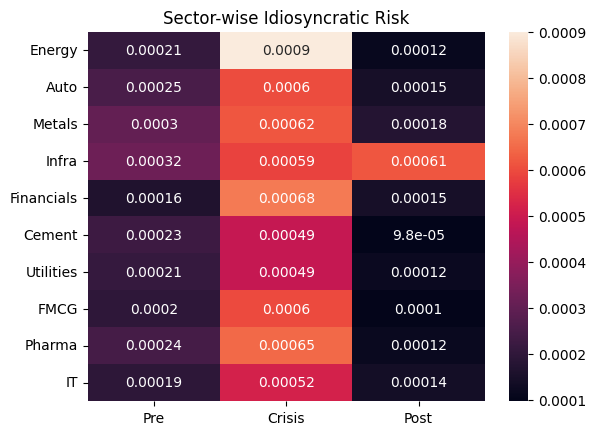

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(summary[["Pre", "Crisis", "Post"]], annot=True)
plt.title("Sector-wise Idiosyncratic Risk")
plt.show()

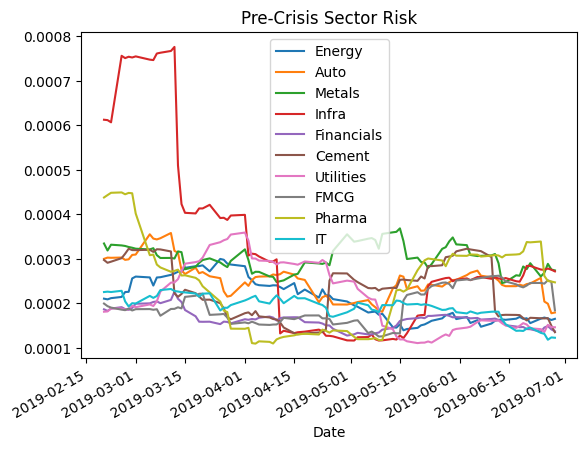

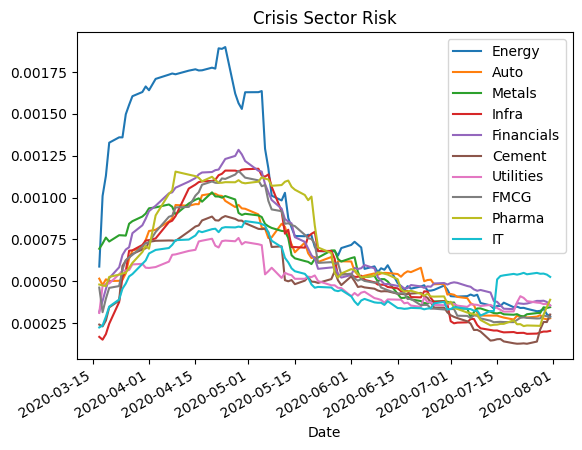

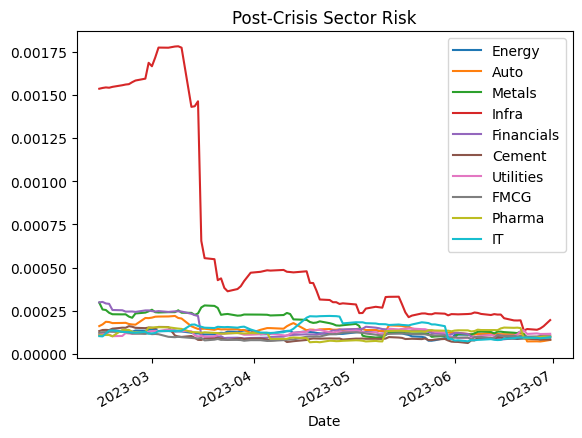

In [19]:
sector_pre.plot(title="Pre-Crisis Sector Risk")
plt.show()

sector_crisis.plot(title="Crisis Sector Risk")
plt.show()

sector_post.plot(title="Post-Crisis Sector Risk")
plt.show()

In [20]:
summary["Crisis vs Pre (%)"] = (summary["Crisis"] - summary["Pre"]) / summary["Pre"] * 100
summary["Post vs Crisis (%)"] = (summary["Post"] - summary["Crisis"]) / summary["Crisis"] * 100

print(summary)

                 Pre    Crisis      Post  Rank (Crisis Risk)  \
Energy      0.000208  0.000900  0.000117                 1.0   
Auto        0.000253  0.000602  0.000146                 5.0   
Metals      0.000302  0.000615  0.000175                 4.0   
Infra       0.000323  0.000585  0.000615                 7.0   
Financials  0.000165  0.000676  0.000147                 2.0   
Cement      0.000229  0.000488  0.000098                10.0   
Utilities   0.000211  0.000488  0.000121                 9.0   
FMCG        0.000196  0.000599  0.000104                 6.0   
Pharma      0.000245  0.000646  0.000118                 3.0   
IT          0.000192  0.000520  0.000141                 8.0   

            Crisis vs Pre (%)  Post vs Crisis (%)  
Energy             333.040356          -87.050242  
Auto               137.968652          -75.815372  
Metals             103.343418          -71.480354  
Infra               81.137272            5.102820  
Financials         310.363795      

In [21]:
import pandas as pd

def get_regression_summary(model, var_name):
    return {
        "Variable": var_name,
        "Coefficient": round(model.params[1], 4),
        "P-value": round(model.pvalues[1], 4),
        "R-squared": round(model.rsquared, 4)
    }

# Regression 1
reg1_pre = get_regression_summary(m1_pre, "Market Volatility")
reg1_crisis = get_regression_summary(m1_crisis, "Market Volatility")
reg1_post = get_regression_summary(m1_post, "Market Volatility")

reg1_results = pd.DataFrame([reg1_pre, reg1_crisis, reg1_post],
                           index=["Pre", "Crisis", "Post"])

print("Regression 1 Results:")
display(reg1_results)

# Regression 2
reg2_pre = get_regression_summary(m2_pre, "Lagged Idio Risk")
reg2_crisis = get_regression_summary(m2_crisis, "Lagged Idio Risk")
reg2_post = get_regression_summary(m2_post, "Lagged Idio Risk")

reg2_results = pd.DataFrame([reg2_pre, reg2_crisis, reg2_post],
                           index=["Pre", "Crisis", "Post"])

print("\nRegression 2 Results:")
display(reg2_results)

Regression 1 Results:


/tmp/ipykernel_3604/323398968.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Coefficient": round(model.params[1], 4),
/tmp/ipykernel_3604/323398968.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "P-value": round(model.pvalues[1], 4),


,Variable,Coefficient,P-value,R-squared
Pre,Market Volatility,-0.0025,0.9831,0.0000
Crisis,Market Volatility,0.3692,0.0000,0.8992
Post,Market Volatility,5.2074,0.0000,0.3144



Regression 2 Results:


/tmp/ipykernel_3604/323398968.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Coefficient": round(model.params[1], 4),
/tmp/ipykernel_3604/323398968.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "P-value": round(model.pvalues[1], 4),


,Variable,Coefficient,P-value,R-squared
Pre,Lagged Idio Risk,0.9781,0.0,0.9641
Crisis,Lagged Idio Risk,0.9984,0.0,0.9921
Post,Lagged Idio Risk,0.9788,0.0,0.9816
